# Offline RL on CartPole-v1 (Kaggle Ready)

This notebook loads the Hugging Face dataset `NathanGavenski/CartPole-v1`, builds an offline dataset, trains a behavior cloning policy, and evaluates it in the environment.

In [5]:
%pip install -q datasets gymnasium torch numpy matplotlib
import sys
import numpy as np
import torch
import gymnasium as gym
from datasets import load_dataset
from matplotlib import pyplot as plt

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Gymnasium:", gym.__version__)

Note: you may need to restart the kernel to use updated packages.
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Torch: 2.10.0+cu128
Gymnasium: 1.2.0


In [6]:
import random
from dataclasses import dataclass
from torch.utils.data import DataLoader, TensorDataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [7]:
dataset_id = "NathanGavenski/CartPole-v1"
dataset_split = "train"
env_id = "CartPole-v1"
use_subset = True
subset_size = 50000
enable_hf_transfer = True
num_updates = 30_000
batch_size = 256
eval_episodes = 10
lr = 3e-4
grad_clip = 5.0
max_episode_steps = 500

In [8]:
import os

def _pick_column(column_names, candidates):
    for name in candidates:
        if name in column_names:
            return name
    return None


print("Loading dataset...")
if enable_hf_transfer:
    os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

hf_ds = load_dataset(dataset_id)
split_name = dataset_split if dataset_split in hf_ds else list(hf_ds.keys())[0]
split_spec = f"{split_name}[:{subset_size}]" if use_subset else split_name
ds = load_dataset(dataset_id, split=split_spec)
print("Dataset loaded:", dataset_id, "split:", split_spec)
print("Columns:", ds.column_names)

obs_col = _pick_column(ds.column_names, ["observations", "obs", "state", "states"])
act_col = _pick_column(ds.column_names, ["actions", "action", "acts"])
rew_col = _pick_column(ds.column_names, ["rewards", "reward"])
next_obs_col = _pick_column(ds.column_names, ["next_observations", "next_obs", "next_state", "next_states"])
done_col = _pick_column(ds.column_names, ["dones", "done", "terminals", "terminal", "terminated"])
trunc_col = _pick_column(ds.column_names, ["truncations", "truncated", "timeouts"])

if obs_col is None or act_col is None or rew_col is None:
    raise RuntimeError("Dataset columns not found. Please check column names.")

env = gym.make(env_id)

obs = np.asarray(ds[obs_col], dtype=np.float32)
actions = np.asarray(ds[act_col], dtype=np.int64).reshape(-1)
rewards = np.asarray(ds[rew_col], dtype=np.float32).reshape(-1)

if next_obs_col is not None:
    next_obs = np.asarray(ds[next_obs_col], dtype=np.float32)
else:
    next_obs = np.concatenate([obs[1:], obs[-1:]], axis=0)

if done_col is not None:
    dones = np.asarray(ds[done_col], dtype=np.float32).reshape(-1)
else:
    dones = np.zeros_like(rewards)

if trunc_col is not None:
    truncs = np.asarray(ds[trunc_col], dtype=np.float32).reshape(-1)
    dones = np.clip(dones + truncs, 0.0, 1.0)

print("Transitions:", obs.shape[0])
print("Obs dim:", obs.shape[1], "Num actions:", env.action_space.n)
print("Reward stats:", rewards.min(), rewards.max(), rewards.mean(), rewards.std())

Loading dataset...


teacher.jsonl:   0%|          | 0.00/74.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/500000 [00:00<?, ? examples/s]

Dataset loaded: NathanGavenski/CartPole-v1 split: train[:50000]
Columns: ['obs', 'actions', 'rewards', 'episode_starts']
Transitions: 50000
Obs dim: 4 Num actions: 2
Reward stats: 1.0 1.0 1.0 0.0


In [9]:
obs_mean = obs.mean(axis=0)
obs_std = obs.std(axis=0) + 1e-8
obs = (obs - obs_mean) / obs_std
next_obs = (next_obs - obs_mean) / obs_std

obs_t = torch.tensor(obs, dtype=torch.float32, device=device)
actions_t = torch.tensor(actions, dtype=torch.int64, device=device)
dataset_t = TensorDataset(obs_t, actions_t)
loader = DataLoader(dataset_t, batch_size=batch_size, shuffle=True, drop_last=True)

print("Data tensors:", obs_t.shape, actions_t.shape)

Data tensors: torch.Size([50000, 4]) torch.Size([50000])


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class BCPolicy(nn.Module):
    def __init__(self, obs_dim, num_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_actions),
        )

    def forward(self, obs):
        return self.net(obs)


obs_dim = obs.shape[1]
num_actions = env.action_space.n
policy = BCPolicy(obs_dim, num_actions).to(device)
opt = torch.optim.Adam(policy.parameters(), lr=lr)

losses = []
policy.train()
for step in range(1, num_updates + 1):
    batch_obs, batch_act = next(iter(loader))
    logits = policy(batch_obs)
    loss = F.cross_entropy(logits, batch_act)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), grad_clip)
    opt.step()
    losses.append(float(loss.item()))
    if step % 5000 == 0:
        print(f"step {step}: bc_loss={loss.item():.4f}")

step 5000: bc_loss=0.0691
step 10000: bc_loss=0.0259
step 15000: bc_loss=0.0155
step 20000: bc_loss=0.0274
step 25000: bc_loss=0.0094
step 30000: bc_loss=0.0060


In [11]:
def evaluate_policy(policy, env, episodes=10):
    returns = []
    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        total = 0.0
        for _ in range(max_episode_steps):
            obs_norm = (np.asarray(obs, dtype=np.float32).reshape(-1) - obs_mean) / (obs_std + 1e-8)
            obs_t = torch.tensor(obs_norm, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                action = torch.argmax(policy(obs_t), dim=1).item()
            obs, reward, terminated, truncated, _ = env.step(action)
            total += float(reward)
            if terminated or truncated:
                break
        returns.append(total)
    return float(np.mean(returns)), float(np.std(returns))


policy.eval()
mean_ret, std_ret = evaluate_policy(policy, env, episodes=eval_episodes)
print(f"BC Return: {mean_ret:.2f} ± {std_ret:.2f}")

BC Return: 500.00 ± 0.00


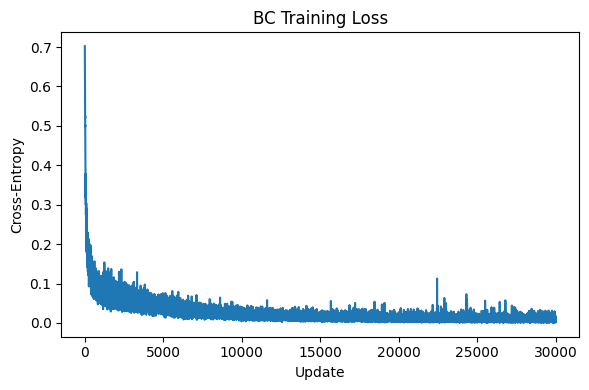

In [12]:
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("BC Training Loss")
plt.xlabel("Update")
plt.ylabel("Cross-Entropy")
plt.tight_layout()
plt.show()